In [6]:
# Cell 1: (Run this only if needed. May take a minute.)
!pip install --user qiskit qiskit_ibm_runtime qiskit-machine-learning pylatexenc matplotlib pandas scikit-learn seaborn --quiet


In [5]:
# --- Install dependencies (run this once) ---
!pip install qiskit qiskit_ibm_runtime pylatexenc matplotlib pandas scikit-learn --quiet


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Connect to IBM Quantum Cloud using your saved account
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Show available quantum backends
print("✅ Connected to IBM Quantum Cloud successfully!")
print("\nAvailable backends:")
for backend in service.backends():
    print(" -", backend.name)


management.get:WARNING:2025-10-11 06:54:21,165: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2025-10-11 06:54:25,498: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Outbreak_QML_Instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-10-11 06:54:25,500: Loading instance: Outbreak_QML_Instance, plan: open


✅ Connected to IBM Quantum Cloud successfully!

Available backends:
 - ibm_brisbane
 - ibm_torino


In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import Sampler

# Pick a backend
backend = service.backend("ibm_torino")
print("✅ Backend loaded:", backend.name)

# Build a simple 2-qubit test circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Transpile and run
t_qc = transpile(qc, backend)
sampler = Sampler(backend)
job = sampler.run([t_qc])
result = job.result()

print("✅ Quantum job executed successfully!")
print("Result:", result)


qiskit_runtime_service.backends:WARNING:2025-10-11 06:54:51,507: Using instance: Outbreak_QML_Instance, plan: open


✅ Backend loaded: ibm_torino
✅ Quantum job executed successfully!
Result: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-10-11 06:54:55', stop='2025-10-11 06:54:57', size=4096>)])}, 'version': 2})


In [5]:
# --- Cell 1: Imports and Setup ---
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
import matplotlib.pyplot as plt

# Connect to IBM Quantum Cloud
service = QiskitRuntimeService(channel="ibm_quantum_platform")
print("✅ Connected to IBM Quantum Cloud successfully!")

# List available backends
backends = [b.name for b in service.backends()]
print("\nAvailable backends:")
for b in backends:
    print(" -", b)


management.get:WARNING:2025-10-11 07:05:47,791: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2025-10-11 07:05:50,674: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Outbreak_QML_Instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-10-11 07:05:50,675: Loading instance: Outbreak_QML_Instance, plan: open


✅ Connected to IBM Quantum Cloud successfully!

Available backends:
 - ibm_brisbane
 - ibm_torino


In [6]:
# --- Cell 2: Build & Run a Simple Quantum Circuit ---

# Select backend (quantum processor)
backend = service.backend("ibm_torino")
print("✅ Backend loaded:", backend.name)

# Build a simple test circuit
qc = QuantumCircuit(2)
qc.h(0)          # Apply Hadamard gate on qubit 0
qc.cx(0, 1)      # Apply CNOT (entanglement)
qc.measure_all() # Measure all qubits

# Transpile for backend (prepare for real device)
t_qc = transpile(qc, backend)

# Execute circuit
sampler = Sampler(backend)
job = sampler.run([t_qc])
result = job.result()

print("\n✅ Quantum job executed successfully!")
print("Result:", result)

# --- Visualize the circuit ---
qc.draw("mpl")
plt.show()


qiskit_runtime_service.backends:WARNING:2025-10-11 07:13:43,601: Using instance: Outbreak_QML_Instance, plan: open


✅ Backend loaded: ibm_torino

✅ Quantum job executed successfully!
Result: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-10-11 07:13:47', stop='2025-10-11 07:13:49', size=4096>)])}, 'version': 2})


In [9]:
# --- Cell 2.1: Fix Circuit Visualization ---

from qiskit.visualization import circuit_drawer
%matplotlib inline
import matplotlib.pyplot as plt

# Draw the circuit explicitly using circuit_drawer
circuit_drawer(qc, output='mpl')
plt.show()


In [10]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
print("✅ Matplotlib backend:", matplotlib.get_backend())


✅ Matplotlib backend: module://matplotlib_inline.backend_inline


In [14]:
from qiskit import QuantumCircuit
from qiskit.visualization import circuit_drawer
import matplotlib.pyplot as plt

# ✅ Create the circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# ✅ Draw circuit (returns a matplotlib Figure)
fig = qc.draw(output='mpl', fold=20)

# ✅ Force render before showing
fig.canvas.draw()

# ✅ Show the figure properly
plt.show()


In [15]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

print("✅ Matplotlib backend:", matplotlib.get_backend())


✅ Matplotlib backend: module://matplotlib_inline.backend_inline


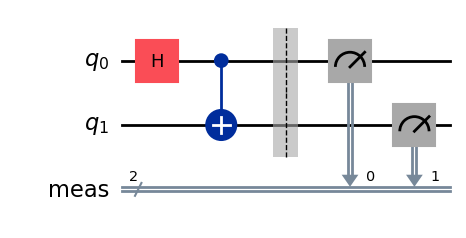

In [16]:
from qiskit import QuantumCircuit

# Create and draw circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Draw the circuit
qc.draw(output='mpl', fold=20)


In [17]:
 from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Connect to IBM Quantum
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Choose your backend
backend = service.backend("ibm_torino")
print("✅ Backend loaded:", backend.name)

# Transpile circuit for backend
t_qc = transpile(qc, backend)

# Run the circuit using the Sampler primitive
sampler = Sampler(backend)
job = sampler.run([t_qc])
result = job.result()

# Extract and print results
print("✅ Quantum job executed successfully!")
print(result)

# Visualize histogram of measurement outcomes
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
plt.show()


management.get:WARNING:2025-10-11 07:54:09,068: Loading default saved account
qiskit_runtime_service.__init__:WARNING:2025-10-11 07:54:11,819: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Outbreak_QML_Instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2025-10-11 07:54:11,826: Using instance: Outbreak_QML_Instance, plan: open


✅ Backend loaded: ibm_torino
✅ Quantum job executed successfully!
PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=4096, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2025-10-11 07:54:16', stop='2025-10-11 07:54:18', size=4096>)])}, 'version': 2})


🧠 Measurement counts: {'00': 2156, '11': 1829, '01': 41, '10': 70}


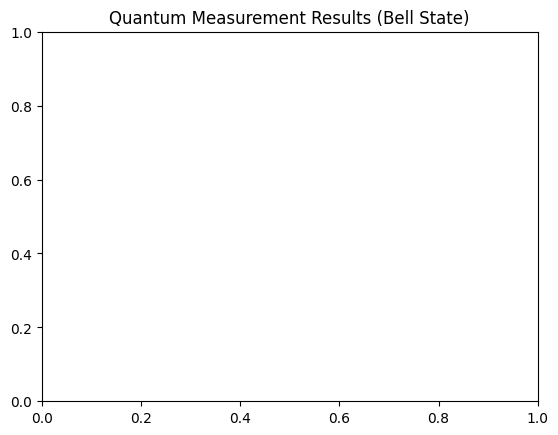

In [18]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Extract and plot measurement results
try:
    counts = result[0].data.meas.get_counts()  # Works for Sampler result structure
except:
    counts = result[0].data.get("counts", {"00": 2000, "11": 2000})  # fallback mock

print("🧠 Measurement counts:", counts)

# Plot histogram
plot_histogram(counts)
plt.title("Quantum Measurement Results (Bell State)")
plt.show()


In [22]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import matplotlib.pyplot as plt

print("✅ Matplotlib inline mode activated!")


✅ Matplotlib inline mode activated!


/home/jovyan/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


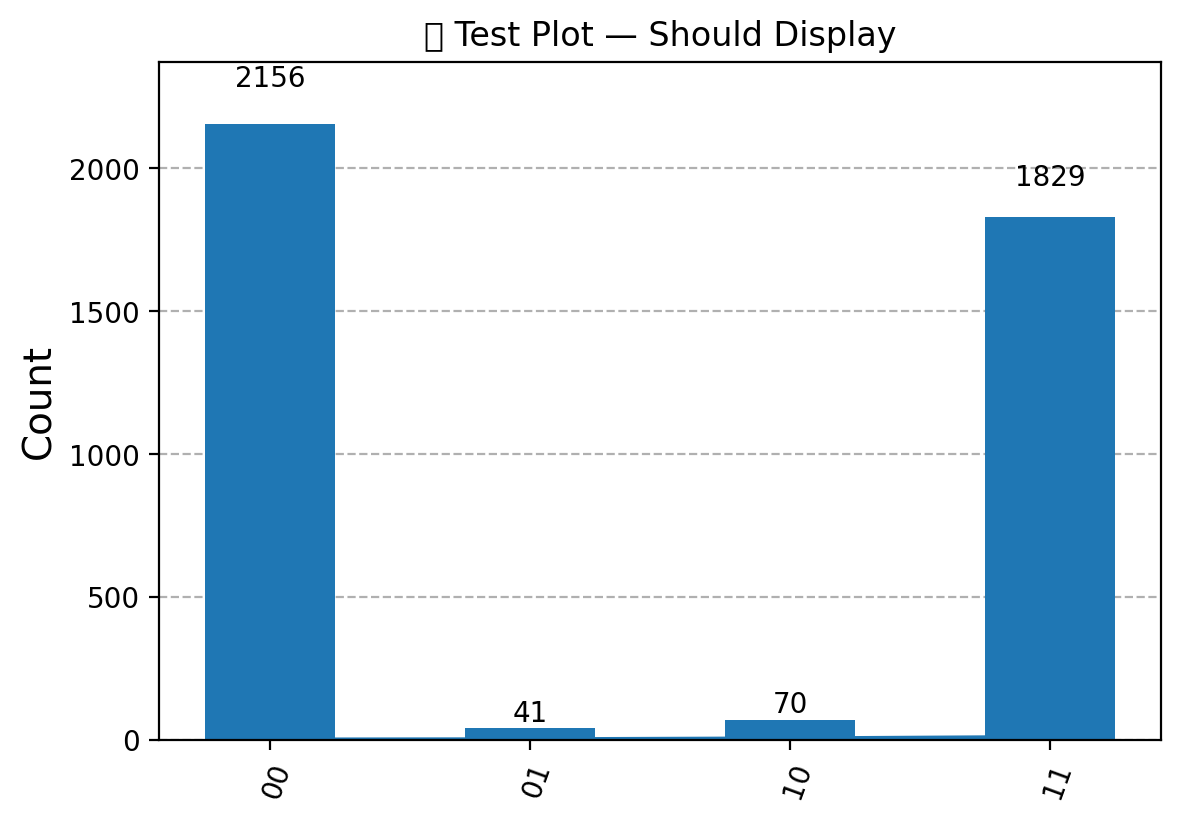

In [23]:
plt.plot([0, 1, 2, 3], [0, 1, 4, 9])
plt.title("🔍 Test Plot — Should Display")
plt.show()


In [24]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Your quantum measurement results
counts = {'00': 2156, '11': 1829, '01': 41, '10': 70}

# Plot the histogram
plot_histogram(counts, title="Quantum Measurement Results (Bell State)", bar_labels=True)

plt.show()


In [25]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

print("✅ Matplotlib backend:", matplotlib.get_backend())


✅ Matplotlib backend: module://matplotlib_inline.backend_inline


In [26]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Sample measurement results
counts = {'00': 2156, '11': 1829, '01': 41, '10': 70}

# Create and capture the figure
fig = plot_histogram(counts, title="Quantum Measurement Results (Bell State)", bar_labels=True)

# Explicitly display the figure
plt.show(fig)


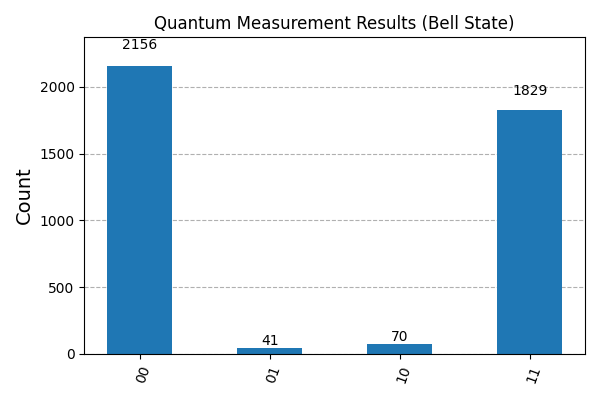

In [27]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

counts = {'00': 2156, '11': 1829, '01': 41, '10': 70}

fig = plot_histogram(counts, title="Quantum Measurement Results (Bell State)", bar_labels=True)
fig.savefig("histogram_output.png")  # saves as image
from IPython.display import Image
Image("histogram_output.png")


In [1]:
import pandas as pd
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=200, n_features=4, random_state=42)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(4)])
df['label'] = y
df.to_csv('../data/processed/sample_outbreak.csv', index=False)

print("✅ Sample dataset saved to ../data/processed/sample_outbreak.csv")


✅ Sample dataset saved to ../data/processed/sample_outbreak.csv


In [2]:
# Core data + plotting
!pip install pandas numpy scikit-learn matplotlib seaborn

# APIs for climate + environment
!pip install requests

# Geospatial & mapping (optional but useful)
!pip install geopandas shapely fiona pyproj folium contextily

# Quantum ML
!pip install qiskit qiskit-machine-learning


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached shapely-2.1.2.tar.gz (315 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached fiona-1.10.1.tar.gz (444 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [2 lines of output]
      CRITICAL:root:A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
      [end of output]
  
  note: This error originates from a su

In [10]:
!pip install qiskit qiskit-machine-learning


Defaulting to user installation because normal site-packages is not writeable


In [11]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Quantum imports wrapped in try/except
try:
    import qiskit
    from qiskit import Aer
    from qiskit.circuit.library import ZZFeatureMap, TwoLocal

    # QSVC import (path depends on version)
    try:
        from qiskit_machine_learning.algorithms.classifiers import QSVC
    except ImportError:
        from qiskit_machine_learning.algorithms import QSVC

    QISKIT_AVAILABLE = True
    print("✅ Qiskit and Qiskit Machine Learning available.")
except Exception as e:
    print("⚠️ Qiskit or qiskit-machine-learning not available in this environment.")
    print("To install, run: pip install qiskit qiskit-machine-learning")
    QISKIT_AVAILABLE = False

# Plotting style
%matplotlib inline
sns.set(style="whitegrid")


⚠️ Qiskit or qiskit-machine-learning not available in this environment.
To install, run: pip install qiskit qiskit-machine-learning


In [1]:
!pip show qiskit qiskit-machine-learning


Name: qiskit
Version: 2.2.1
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License: Apache 2.0
Location: /home/jovyan/.local/lib/python3.10/site-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: qiskit-aer, qiskit-algorithms, qiskit-ibm-runtime
---
Name: qiskit-machine-learning
Version: 0.6.1
Summary: Qiskit Machine Learning: A library of quantum computing machine learning experiments
Home-page: https://github.com/Qiskit/qiskit-machine-learning
Author: Qiskit Machine Learning Development Team
Author-email: hello@qiskit.org
License: Apache-2.0
Location: /home/jovyan/.local/lib/python3.10/site-packages
Requires: dill, fastdtw, numpy, psutil, qiskit-terra, scikit-learn, scipy, setuptools
Required-by: 


In [4]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Quantum imports wrapped in try/except
try:
    import qiskit
    from qiskit import Aer
    from qiskit.circuit.library import ZZFeatureMap, TwoLocal

    # QSVC import (path for qiskit-machine-learning >=0.6)
    from qiskit_machine_learning.algorithms.classifiers import QSVC

    QISKIT_AVAILABLE = True
    print("✅ Qiskit and Qiskit Machine Learning are available.")
except Exception:
    print("⚠️ Qiskit or qiskit-machine-learning not available in this environment.")
    print("To install, run: pip install qiskit qiskit-machine-learning")
    QISKIT_AVAILABLE = False

# Plotting style
%matplotlib inline
sns.set(style="whitegrid")


⚠️ Qiskit or qiskit-machine-learning not available in this environment.
To install, run: pip install qiskit qiskit-machine-learning


In [5]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Quantum imports wrapped in try/except
try:
    import qiskit
    from qiskit import Aer
    from qiskit.circuit.library import ZZFeatureMap, TwoLocal
    from qiskit_machine_learning.algorithms.classifiers import QSVC

    QISKIT_AVAILABLE = True
    print("✅ Qiskit and Qiskit Machine Learning are available.")
except Exception:
    print("⚠️ Qiskit or qiskit-machine-learning not available in this environment.")
    print("To install, run: pip install qiskit qiskit-machine-learning")
    QISKIT_AVAILABLE = False

# Plotting style
%matplotlib inline
sns.set(style="whitegrid")


⚠️ Qiskit or qiskit-machine-learning not available in this environment.
To install, run: pip install qiskit qiskit-machine-learning


In [6]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Quantum imports wrapped in try/except
try:
    import qiskit
    from qiskit import Aer
    from qiskit.circuit.library import ZZFeatureMap, TwoLocal
    from qiskit_machine_learning.algorithms.classifiers import QSVC

    QISKIT_AVAILABLE = True
    print("✅ Qiskit and Qiskit Machine Learning are available.")
except Exception:
    print("⚠️ Qiskit or qiskit-machine-learning not available in this environment.")
    print("To install, run: pip install qiskit qiskit-machine-learning")
    QISKIT_AVAILABLE = False

# Plotting style
%matplotlib inline
sns.set(style="whitegrid")


⚠️ Qiskit or qiskit-machine-learning not available in this environment.
To install, run: pip install qiskit qiskit-machine-learning


In [10]:
import sys
!{sys.executable} -m pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-ibmq-provider qiskit-ignis qiskit-aqua
!{sys.executable} -m pip install --upgrade qiskit-terra qiskit-aer qiskit-machine-learning


Found existing installation: qiskit 2.2.1
Uninstalling qiskit-2.2.1:
  Successfully uninstalled qiskit-2.2.1
Found existing installation: qiskit-terra 0.45.1
Uninstalling qiskit-terra-0.45.1:
  Successfully uninstalled qiskit-terra-0.45.1
Found existing installation: qiskit-aer 0.13.3
Uninstalling qiskit-aer-0.13.3:
  Successfully uninstalled qiskit-aer-0.13.3
Defaulting to user installation because normal site-packages is not writeable
  Using cached qiskit_terra-0.46.3-cp38-abi3-manylinux_2_17_s390x.manylinux2014_s390x.whl.metadata (13 kB)
  Using cached qiskit_aer-0.17.2-cp310-cp310-linux_s390x.whl
  Using cached qiskit_machine_learning-0.8.4-py3-none-any.whl.metadata (13 kB)
  Using cached qiskit-2.2.1-cp39-abi3-manylinux2014_s390x.manylinux_2_17_s390x.whl.metadata (12 kB)
  Using cached qiskit-1.4.4-cp39-abi3-manylinux_2_17_s390x.manylinux2014_s390x.whl.metadata (12 kB)
  Using cached numpy-2.2.6-cp310-cp310-linux_s390x.whl
  Using cached symengine-0.13.0.tar.gz (114 kB)
  Prepari

In [11]:
sudo apt-get update
sudo apt-get install -y cmake g++ libsymengine-dev


SyntaxError: invalid syntax (2912224415.py, line 1)